<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Maximally_entangled_Bell_state_and_its_decoherence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

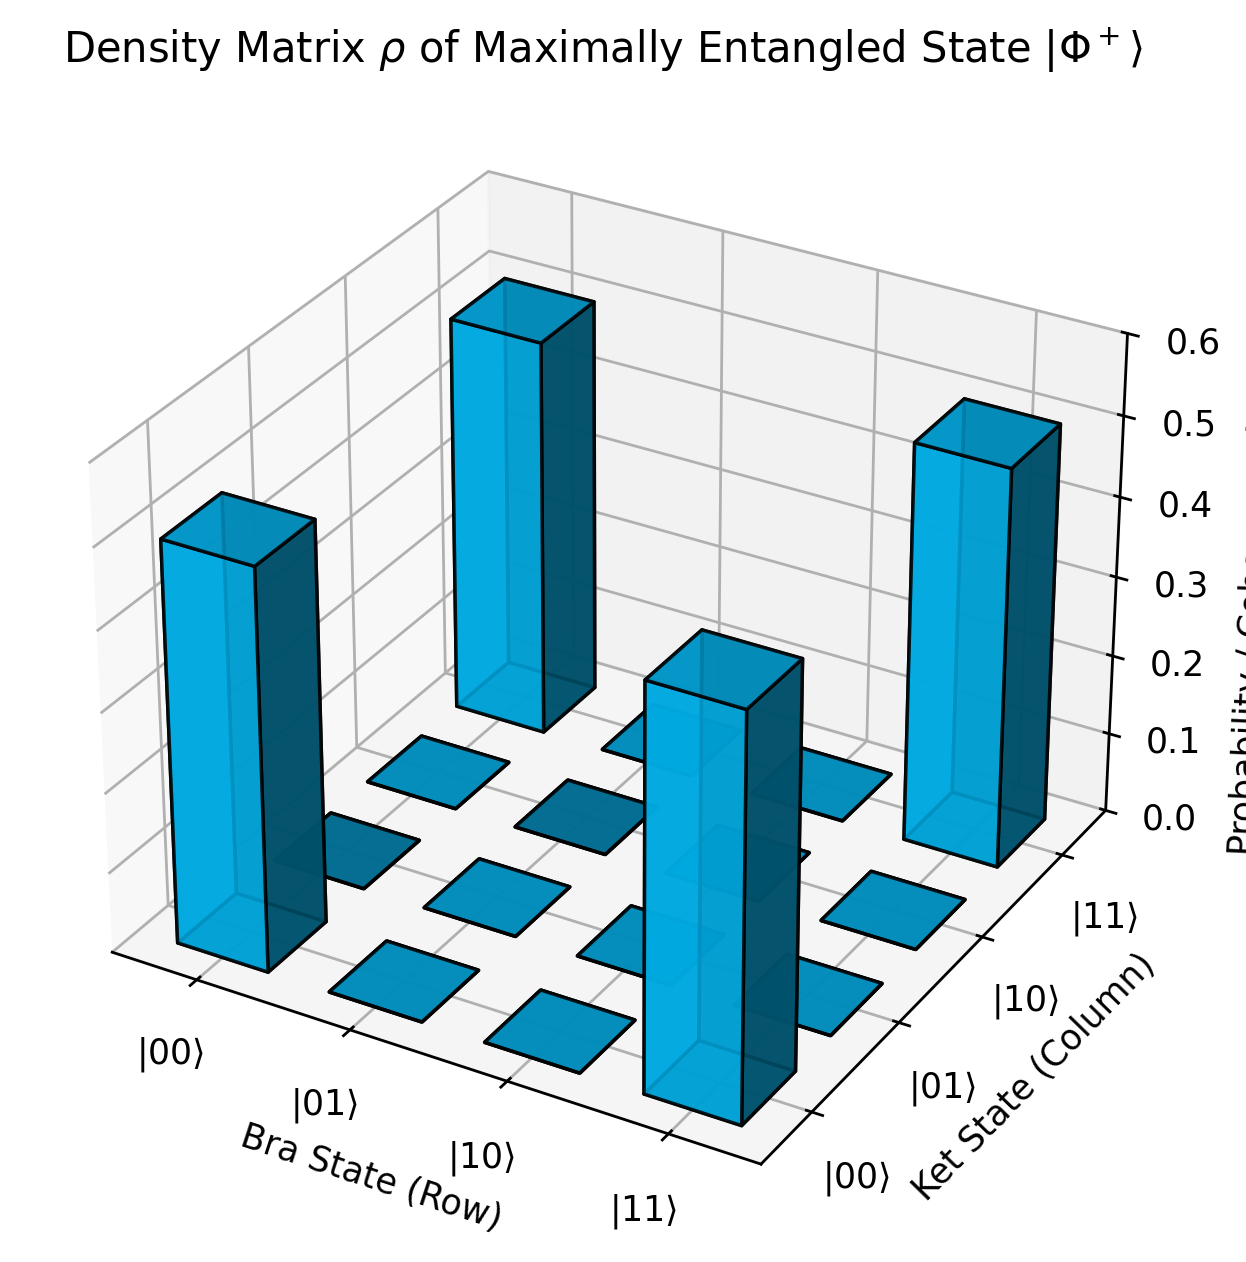

In [ ]:
"""
Simulates and plots the density matrix of a maximally entangled Bell state.

This module provides a pure NumPy and Matplotlib implementation to visualize
the quantum coherence and classical probabilities of an entangled state.
Compliant with PEP 8 and PEP 257. Designed for Google Colaboratory.
"""

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =============================================================================
# CONTROL KNOBS
# Adjust these parameters to easily modify the environment and visualization.
# =============================================================================
PLOT_DPI = 250               # Resolution for Colab rendering
BAR_COLOR = '#00BFFF'        # Deep sky blue for the matrix bars
BAR_EDGE_COLOR = 'black'     # Outline color for visual clarity
BAR_ALPHA = 0.85             # Transparency for the 3D bars
# =============================================================================

def generate_bell_state_matrix() -> np.ndarray:
    """
    Generate the density matrix for the maximally entangled state |Phi+>.

    Returns:
        np.ndarray: A 4x4 complex density matrix representing the Bell state.
    """
    # Define single qubit basis states
    ket_0 = np.array([1, 0])
    ket_1 = np.array([0, 1])

    # Construct the two-qubit states |00> and |11> using tensor products
    ket_00 = np.kron(ket_0, ket_0)
    ket_11 = np.kron(ket_1, ket_1)

    # Form the superposition state |Phi+> = (|00> + |11>) / sqrt(2)
    phi_plus = (ket_00 + ket_11) / np.sqrt(2)

    # Calculate the density matrix rho = |Phi+><Phi+|
    # Using outer product of the state vector with its complex conjugate transpose
    rho = np.outer(phi_plus, phi_plus.conj())

    return rho

def plot_density_matrix_cityscape(rho: np.ndarray) -> None:
    """
    Render a 3D bar plot (cityscape) of the real part of a density matrix.

    Args:
        rho (np.ndarray): The 4x4 density matrix to visualize.
    """
    # Apply the DPI setting for high-resolution Colab rendering
    plt.rcParams['figure.dpi'] = PLOT_DPI

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    # Matrix dimensions
    x_dim, y_dim = rho.shape

    # Create coordinate grid for the bars
    x_pos, y_pos = np.meshgrid(np.arange(x_dim), np.arange(y_dim))
    x_pos = x_pos.flatten()
    y_pos = y_pos.flatten()
    z_pos = np.zeros_like(x_pos)

    # Bar dimensions
    dx = 0.6 * np.ones_like(z_pos)
    dy = 0.6 * np.ones_like(z_pos)

    # We plot the real part of the density matrix (imaginary is 0 for this state)
    dz = np.real(rho).flatten()

    # Construct the 3D bars
    ax.bar3d(x_pos, y_pos, z_pos, dx, dy, dz,
             color=BAR_COLOR, alpha=BAR_ALPHA, edgecolor=BAR_EDGE_COLOR)

    # Format the axes to reflect the two-qubit basis states
    basis_labels = [r'$|00\rangle$', r'$|01\rangle$', r'$|10\rangle$', r'$|11\rangle$']
    ax.set_xticks(np.arange(x_dim) + 0.3)
    ax.set_yticks(np.arange(y_dim) + 0.3)
    ax.set_xticklabels(basis_labels)
    ax.set_yticklabels(basis_labels)

    ax.set_zlim(0, 0.6)
    ax.set_title(r"Density Matrix $\rho$ of Maximally Entangled State $|\Phi^+\rangle$")
    ax.set_xlabel("Bra State (Row)")
    ax.set_ylabel("Ket State (Column)")
    ax.set_zlabel("Probability / Coherence Amplitude")

    # Render plot directly in Colab
    plt.show()

if __name__ == "__main__":
    density_matrix = generate_bell_state_matrix()
    plot_density_matrix_cityscape(density_matrix)

In [ ]:
# =============================================================================
# CONTROL KNOBS
# Adjust these variables to install different packages or modify environments.
# =============================================================================
# TARGET_PACKAGE: The specific library to install (e.g., "qutip", "numpy")
# SYSTEM_FLAG: Required in Colab to bypass VEnv protections ("--system")
# =============================================================================

# 1. Bootstrap the uv package manager into the environment
!pip install uv

# 2. Execute the accelerated installation using uv
!uv pip install --system qutip

Using Python 3.12.13 environment at: /usr
Checked 1 package in 76ms


/usr/local/lib/python3.12/dist-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


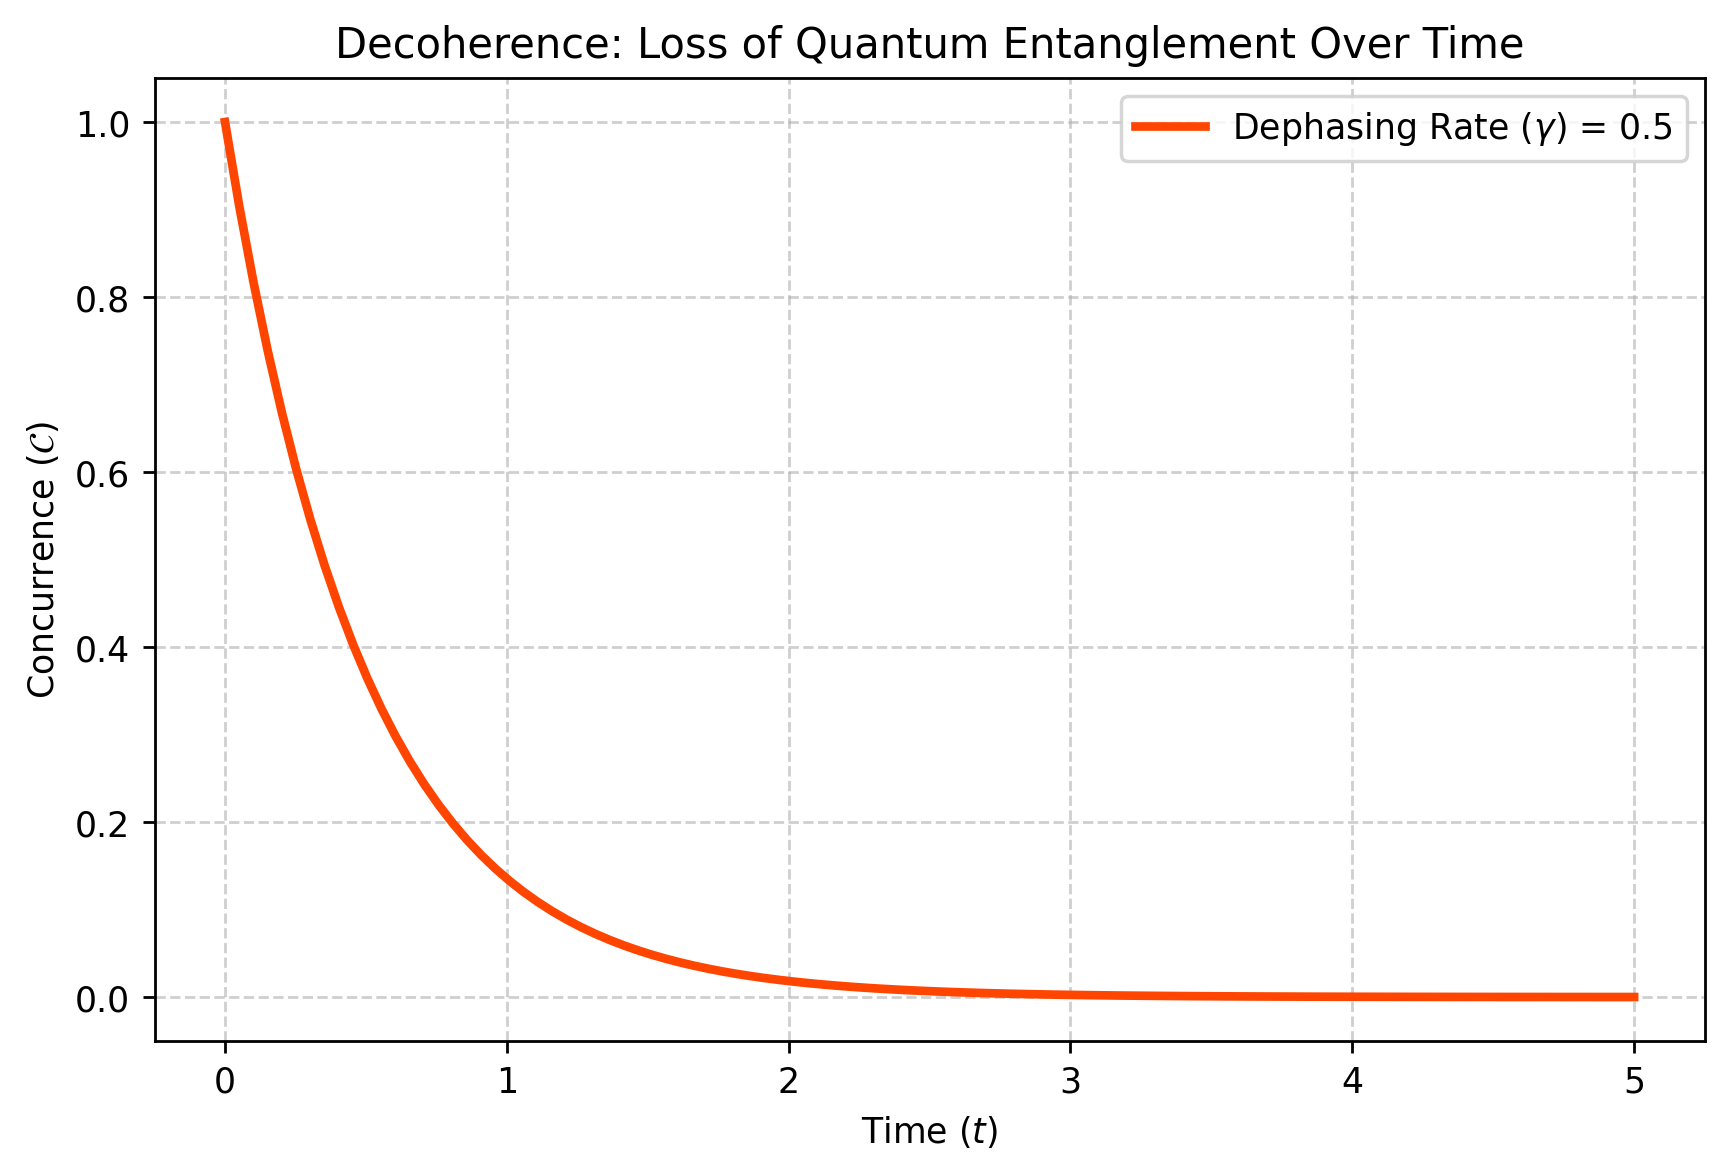

In [ ]:
"""
Simulates the decoherence of a Bell state using the Lindblad Master Equation.

This script uses QuTiP to model an Open Quantum System experiencing
pure dephasing. It calculates and plots the decay of entanglement
(Concurrence) over time. Compliant with PEP 8 and PEP 257.
Designed for Google Colaboratory.
"""

# =============================================================================
# ENVIRONMENT SETUP
# Run these commands in a separate Colab cell if dependencies are missing:
# !pip install uv
# !uv pip install --system qutip matplotlib numpy
# =============================================================================

import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

# =============================================================================
# PHYSICAL & VISUALIZATION CONTROL KNOBS
# =============================================================================
PLOT_DPI = 250                 # Colab inline rendering resolution
DEPHASING_RATE = 0.5           # Gamma (gamma): Rate of phase-flip errors
TOTAL_TIME = 5.0               # Total simulation time in arbitrary units
TIME_STEPS = 100               # Number of temporal evaluation points
PLOT_COLOR = '#FF4500'         # Orange-red for the decay curve
# =============================================================================

def simulate_decoherence() -> None:
    """
    Solve the Lindblad master equation for a dephasing Bell state
    and plot the decay of its concurrence over time.
    """
    # Apply high resolution setting for Colab rendering
    plt.rcParams['figure.dpi'] = PLOT_DPI

    # 1. Define the initial state (Maximally entangled Bell state |Phi+>)
    ket_0 = qt.basis(2, 0)
    ket_1 = qt.basis(2, 1)
    ket_00 = qt.tensor(ket_0, ket_0)
    ket_11 = qt.tensor(ket_1, ket_1)

    # Construct the initial density matrix
    bell_state = (ket_00 + ket_11).unit()
    rho_initial = bell_state * bell_state.dag()

    # 2. Define the Hamiltonian
    # We set H to a zero matrix. We are isolating the effect
    # of pure environmental dephasing without intrinsic energy evolution.
    H = qt.tensor(qt.qzero(2), qt.qzero(2))

    # 3. Define the Collapse Operators (c_ops)
    # We apply independent dephasing (Pauli-Z) to both Qubit 0 and Qubit 1.
    # The magnitude of the collapse operator is scaled by the square root
    # of the dephasing rate (Gamma).
    c_op_qubit_0 = np.sqrt(DEPHASING_RATE) * qt.tensor(qt.sigmaz(), qt.qeye(2))
    c_op_qubit_1 = np.sqrt(DEPHASING_RATE) * qt.tensor(qt.qeye(2), qt.sigmaz())
    c_ops = [c_op_qubit_0, c_op_qubit_1]

    # 4. Define the time array
    tlist = np.linspace(0, TOTAL_TIME, TIME_STEPS)

    # 5. Solve the Lindblad Master Equation
    # qt.mesolve computes the evolution of the density matrix rho(t)
    result = qt.mesolve(H, rho_initial, tlist, c_ops, [])

    # 6. Extract Concurrence at each time step
    # result.states contains the density matrix at each point in tlist
    concurrence_values = [qt.concurrence(rho_t) for rho_t in result.states]

    # 7. Plot the results
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(
        tlist,
        concurrence_values,
        color=PLOT_COLOR,
        linewidth=2.5,
        label=rf'Dephasing Rate ($\gamma$) = {DEPHASING_RATE}'
    )

    ax.set_title(r"Decoherence: Loss of Quantum Entanglement Over Time")
    ax.set_xlabel("Time ($t$)")
    ax.set_ylabel(r"Concurrence ($\mathcal{C}$)")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()

    # Display inline exclusively (never saved to disk)
    plt.show()

if __name__ == "__main__":
    simulate_decoherence()